###### Abschlussprojekt Big Data Machine Learning (1/4) - Ali Abdelatty (3539251)

## 1. Maschinelles Lernen mit dem California Housing Datensatz und sklearn

### 1.1 Entscheidungsbaum

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

##### 1.1.1 Datensatz laden

In [2]:
housing = fetch_california_housing()

print("Datensatz ist geladen")
print(f"\nShape: {housing.data.shape}")

Datensatz ist geladen

Shape: (20640, 8)


##### 1.1.2 Datensatz aufteilen in Training (80%) und Test (20%)

In [3]:
# Aufteilung in Features (X) und Target (y)
X = housing.data
y = housing.target

# Train-Test-Split durchführen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datensatz aufgeteilt:")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Test Samples: {X_test.shape[0]}")
print(f"Training Anteil: {X_train.shape[0] / (X_train.shape[0] + X_test.shape[0]):.1%}")
print(f"Test Anteil: {X_test.shape[0] / (X_train.shape[0] + X_test.shape[0]):.1%}")

Datensatz aufgeteilt:
Training Samples: 16512
Test Samples: 4128
Training Anteil: 80.0%
Test Anteil: 20.0%


##### 1.1.3 ML Aufgabe & Verfahren
Es handelt sich um eine **Regressionsaufgabe**, weil wir  einen *kontinuierlichen numerischen* Wert (Hauspreis) prädizieren, nicht kategorische Klassen. Der Target ist eine reelle Zahl.

**Mögliche ML-Verfahren:**
- Lineare Regression
- Random Forrest Regression
- Support Vector Regression
- Gradient Boosting Regressor
- Neuronale Netze

##### 1.1.4 Funktionsweise Entscheidungsbaum für Regression
Ein Entscheidungsbaum unterteilt den Datenraum rekursiv in kleinere Bereiche.
1. **Splitting:** Der Algorithmus sucht an jedem Knoten das Feature und den Schwellenwert (Threshold), der die Daten am besten teilt. Das Ziel ist die Minimierung der Varianz (oder des MSE) in den Kind-Knoten.
2. **Leaf Nodes:** Dieser Prozess wird wiederholt, bis ein Abbruchkriterium erreicht ist (maximale Tiefe des Baums).
3. **Prädiktion:** Der vorhergesagte Wert für ein neues Datenblatt ist der Durchschnittswert (Mean) der Zielvariablen aller Trainingsdatenpunkte, die in diesem Blattknoten liegen.

##### 1.1.5 Entscheidungsbaum trainieren

In [4]:
# Modell initialisieren
dt_regressor = DecisionTreeRegressor(random_state=42)

# Modell auf Trainingsdaten trainieren
dt_regressor.fit(X_train, y_train)

print("Entscheidungsbaum erfolgreich trainiert!")
print(f"Tiefe des Baums: {dt_regressor.get_depth()}")
print(f"Anzahl Blätter: {dt_regressor.get_n_leaves()}")

Entscheidungsbaum erfolgreich trainiert!
Tiefe des Baums: 34
Anzahl Blätter: 15854


##### 1.1.6 Mean Squared Error berechnen

In [5]:
# Vorhersagen auf Testdaten
y_pred = dt_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (MSE) auf Testdaten: {mse:.4f}")

Mean Squared Error (MSE) auf Testdaten: 0.4952


##### 1.1.7 Visualisierung Vorhersage vs. echte Werte

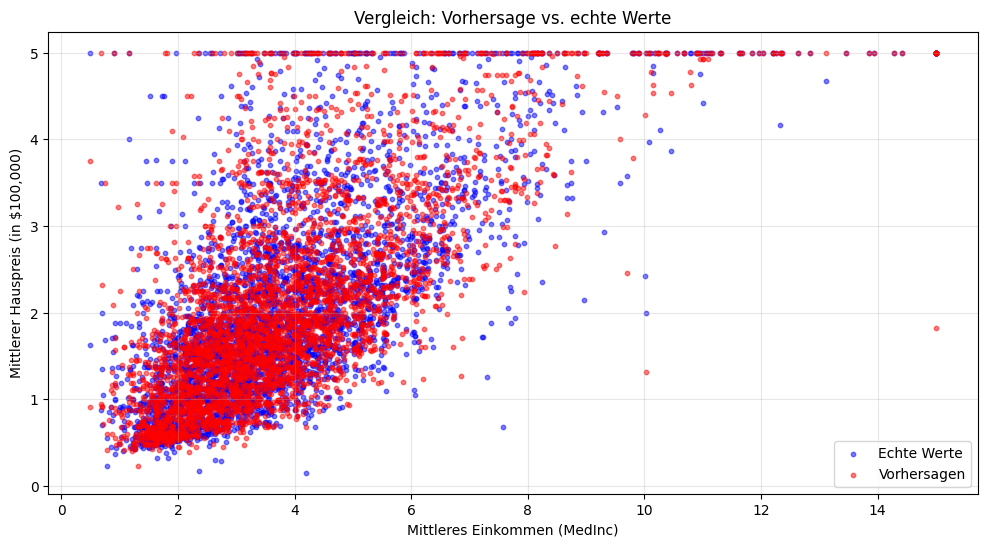

In [6]:
# MedInc als X-Achse, erstes Feature (Index 0)
medinc_test = X_test[:, 0]

# Plot erstellen
plt.figure(figsize=(12, 6))

# Echte Werte in Blau
plt.scatter(medinc_test, y_test, alpha=0.5, s=10, label='Echte Werte', color='blue')

# Vorhersagen in Rot
plt.scatter(medinc_test, y_pred, alpha=0.5, s=10, label='Vorhersagen', color='red')

plt.title('Vergleich: Vorhersage vs. echte Werte')
plt.xlabel('Mittleres Einkommen (MedInc)')
plt.ylabel('Mittlerer Hauspreis (in $100,000)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**Beobachtung:**
- Die Vorhersagen bilden eine horizontale Linie bei y=5 (auch bei anderen bestimmten Preiswerten erkennbar). Das liegt daran, dass beim Entscheidungsbaum für bestimmte Bereiche des MedInc die Datenpunkte im selben Blattknoten landen und erhalten denselben Vorhersagewert (den Durchschnitt dieses Blattes).
Im Vergleich dazu bilden die echten Werte (blau) eine kontinuierliche Wolke. Diese wird von den roten Punkte stark nachgemacht was daraufhin deuten kann, das der Entscheidungsbaum möglicherweise zu sehr an die Trainingsdaten angepasst ist *(Overfitting)*.

-----------------------

### 1.2 Random Forest Regressor

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

##### 1.2.1 Vor- Nachteile Random Forrest Regressor (gegenüber einzelner Entscheidungsbäume)

| Vorteile                                     | Nachteile                 |
|----------------------------------------------|---------------------------|
| + reduziertes Overfitting (niedrige Varianz) | - höherer Rechenaufwand   |
| + höhere Genauigkeit                         | - höherer Speicherbedarf  |
| + robuster (gegen Rauschen, Ausreißer..)     | - längere Trainingszeiten |

##### 1.2.2 Trainieren eines Random Forest Regressor

In [8]:
# Daten aufteilen
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest initialisieren und trainieren
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X_train_rf, y_train_rf)

print("Random Forest Regressor erfolgreich trainiert!")
print(f"Anzahl Bäume: {rf_regressor.n_estimators}")
print(f"Max. Tiefe: {rf_regressor.max_depth}")

Random Forest Regressor erfolgreich trainiert!
Anzahl Bäume: 100
Max. Tiefe: None


##### 1.2.3 MSE und R2-Score evaluieren

In [9]:
# Vorhersagen
y_train_pred_rf = rf_regressor.predict(X_train_rf)
y_test_pred_rf = rf_regressor.predict(X_test_rf)

# Metriken berechnen
mse_train_rf = mean_squared_error(y_train_rf, y_train_pred_rf)
mse_test_rf = mean_squared_error(y_test_rf, y_test_pred_rf)
r2_train_rf = r2_score(y_train_rf, y_train_pred_rf)
r2_test_rf = r2_score(y_test_rf, y_test_pred_rf)

print("Random Forest Evaluation\n")
print(f"  MSE (Train):  {mse_train_rf:.4f}")
print(f"  R2 (Train):   {r2_train_rf:.4f}\n")
print(f"  MSE (Test):  {mse_test_rf:.4f}")
print(f"  R2 (Test):   {r2_test_rf:.4f}")

Random Forest Evaluation

  MSE (Train):  0.0353
  R2 (Train):   0.9736

  MSE (Test):  0.2554
  R2 (Test):   0.8051


##### 1.2.4 Hyperparameter-Training

In [10]:
# Parameter-Grid definieren (6 Kombis)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20]
}

# GridSearchCV initialisieren
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # war zuuuu langsam sonst
    verbose=1
)

# Training durchführen
grid_search.fit(X_train_rf, y_train_rf)
print("Hyperparameter-Tuning abgeschlossen!")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Hyperparameter-Tuning abgeschlossen!


##### 1.2.5 Beste Hyperparameter & MSE

In [11]:
# Bestes Modell auswählen
best_rf = grid_search.best_estimator_

# Vorhersagen mit bestem Modell
y_train_pred_best = best_rf.predict(X_train_rf)
y_test_pred_best = best_rf.predict(X_test_rf)

# MSE berechnen
mse_train_best = mean_squared_error(y_train_rf, y_train_pred_best)
mse_test_best = mean_squared_error(y_test_rf, y_test_pred_best)

print("Beste Hyperparameter")
print(f"n_estimators: {grid_search.best_params_['n_estimators']}")
print(f"max_depth:    {grid_search.best_params_['max_depth']}\n")

print("Evaluation beste Hyperparametern")
print(f"MSE Trainingsdaten: {mse_train_best:.4f}")
print(f"MSE Testdaten:      {mse_test_best:.4f}")
print(f"\nBester CV-Score (neg. MSE): {grid_search.best_score_:.4f}")

Beste Hyperparameter
n_estimators: 200
max_depth:    20

Evaluation beste Hyperparametern
MSE Trainingsdaten: 0.0363
MSE Testdaten:      0.2546

Bester CV-Score (neg. MSE): -0.2656


##### 1.2.6 Bootstrapping & Feature Selection
- **Warum?** Durch Bootstrapping und die Begrenzung der Features (max_features) wird sichergestellt, dass die einzelnen Bäume im Forest möglichst unabhängig voneinander sind. Würde jeder Baum alle Daten und alle Features sehen, wären sie fast identisch und der Vorteil der Constellation ginge verloren.
- **Auswirkungen:** Der Bias kann sich leicht erhöhen, da die einzelnen Bäume durch die eingeschränkten Daten/Features potenziell schwächer ("underfitted") sind als ein einzelner, voll optimierter Baum. Die Varianz wird stark reduziert, wegen Averaging vieler diverser Bäume. Also erlaubt sich der Random Forest einen leicht höheren Bias, um eine deutlich niedrigere Varianz zu erreichen (insgesamt kleinerer Gesamtfehler)

---------

### 1.3 Neuronales Netzwerk

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_absolute_error

2026-02-13 02:31:59.151001: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/alimounir/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


##### 1.3.1 Datensatz Aufteilung Training (70%), Validierung (15%), Test (15%)

In [13]:
# Zuerst 70% Training, 30% Rest
X_train_nn, X_rest, y_train_nn, y_rest = train_test_split(X, y, test_size=0.3, random_state=42)

# Dann die 30% in jeweils 15% Validierung und 15% Test aufteilen
X_val_nn, X_test_nn, y_val_nn, y_test_nn = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42)

print("Datenaufteilung:")
print(f"Training:     {X_train_nn.shape[0]} Samples ({X_train_nn.shape[0]/X.shape[0]:.1%})")
print(f"Validierung:  {X_val_nn.shape[0]} Samples ({X_val_nn.shape[0]/X.shape[0]:.1%})")
print(f"Test:         {X_test_nn.shape[0]} Samples ({X_test_nn.shape[0]/X.shape[0]:.1%})")

Datenaufteilung:
Training:     14448 Samples (70.0%)
Validierung:  3096 Samples (15.0%)
Test:         3096 Samples (15.0%)


##### 1.3.2 Neuronales Netzwerk mit einer Hidden Layer erstellen

In [14]:
# Funktion zum Erstellen des Modells
def create_model(neurons, learning_rate):

    model = keras.Sequential([
        layers.Dense(neurons, activation='relu', input_shape=(X_train_nn.shape[1],)),
        layers.Dense(1)  # Output Layer für Regression (keine Aktivierung)
    ])
    
    # Modell kompilieren
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model

In [15]:
# Beispiel-Modell erstellen
example_model = create_model(neurons=64, learning_rate=0.01)
print("Modell-Architektur:")
example_model.summary()

Modell-Architektur:


/Users/alimounir/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

##### 1.3.3 Hyperparameter-Optimierung

In [16]:
# Hyperparameter-Grid definieren
neurons_options = [32, 64, 128]
learning_rate_options = [0.001, 0.01]

# Ergebnisse speichern
results = []

print("Starte Hyperparameter-Optimierung...\n")

Starte Hyperparameter-Optimierung...



In [17]:
# Alle Kombinationen durchprobieren
for neurons in neurons_options:
    for learning_rate in learning_rate_options:
        print(f"Training mit neurons={neurons}, learning_rate={learning_rate}")
        
        # Modell erstellen
        model = create_model(neurons=neurons, learning_rate=learning_rate)
        
        # Modell trainieren
        history = model.fit(
            X_train_nn, y_train_nn,
            validation_data=(X_val_nn, y_val_nn),
            epochs=100,
            batch_size=32
        )
        
        # Finale Metriken auf Validierungsdaten
        val_loss = history.history['val_loss'][-1]
        val_mae = history.history['val_mae'][-1]
        
        # Ergebnisse speichern
        results.append({
            'neurons': neurons,
            'learning_rate': learning_rate,
            'val_loss': val_loss,
            'val_mae': val_mae,
            'model': model,
            'history': history
        })
        
        print(f"  → Validierung MAE: {val_mae:.4f}, Loss: {val_loss:.4f}\n")

print("Hyperparameter-Optimierung abgeschlossen!")

Training mit neurons=32, learning_rate=0.001
Epoch 1/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 482.3509 - mae: 9.3699 - val_loss: 15.3039 - val_mae: 2.8898
Epoch 2/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.8689 - mae: 1.4177 - val_loss: 1.1170 - val_mae: 0.8371
Epoch 3/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.1992 - mae: 0.8352 - val_loss: 0.9777 - val_mae: 0.7743
Epoch 4/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9297 - mae: 0.7475 - val_loss: 0.9065 - val_mae: 0.7068
Epoch 5/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9916 - mae: 0.7497 - val_loss: 0.8489 - val_mae: 0.7134
Epoch 6/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9938 - mae: 0.7341 - val_loss: 0.9450 - val_mae: 0.7710
Epoch 7/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7826 - mae: 0.6701 - val_loss: 0.7540 - val_mae: 0.6519
Epoch 8/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7667 - mae: 0.6631 - val_loss: 0.7014 - val_mae: 0.6274


##### 1.3.4 Bedeutung Neuronen & Learning Rate
- **Anzahl Neuronen:** Stellt Kapazität/Komplexität des Modells dar. Mehr Neuronen = Höhere Ausdruckkraft. Zu viele Neuronen Modell wird komplex (Overfitting) mit hoher Varianz und schlechter Generalisierung. Bei zu wenigen Neuronen ist das Modell zu simpel (Underfitting) und kann komplexe Muster nicht lernnen
- **Learning Rate:** steuert die Schrittweite bei der Anpassung der Gewichte während des Gradientenverfahrens. Je höher desto schneller wird gelernt, aber Risiko dass das Modell über das Minimum hinausschießt und instail wird. Je niedriger die Lernrate desto stabiler aber zeitaufwändiger.

##### 1.3.5 Beste Hyperparameter & MAE

In [18]:
# Beste Konfiguration finden (niedrigster Validierungs-MAE)
best_result = min(results, key=lambda x: x['val_mae'])

print("Beste Hyperparameter")
print(f"Neuronen:  {best_result['neurons']}")
print(f"Learning Rate: {best_result['learning_rate']}\n")

Beste Hyperparameter
Neuronen:  64
Learning Rate: 0.01



In [20]:
# Bestes Modell extrahieren
best_model = best_result['model']

# Vorhersagen auf allen drei Datensets
y_train_pred_nn = best_model.predict(X_train_nn).flatten()
y_val_pred_nn = best_model.predict(X_val_nn).flatten()
y_test_pred_nn = best_model.predict(X_test_nn).flatten()

# MAE berechnen
mae_train = mean_absolute_error(y_train_nn, y_train_pred_nn)
mae_val = mean_absolute_error(y_val_nn, y_val_pred_nn)
mae_test = mean_absolute_error(y_test_nn, y_test_pred_nn)

print("Evaluation besten Modells (MAE)")
print(f"Trainingsdaten:   {mae_train:.4f}")
print(f"Validierungsdaten: {mae_val:.4f}")
print(f"Testdaten:        {mae_test:.4f}")

452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step
Evaluation besten Modells (MAE)
Trainingsdaten:   0.5346
Validierungsdaten: 0.5441
Testdaten:        0.5252
